In [2]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize_scalar
import mpmath as mp
import matplotlib.pyplot as plt

mp.mp.dps = 50

In [33]:
def probit_moment(k, N, r):        # r = 1 or 2
    beta_norm = mp.beta(k, N+1-k)
    SQRT2   = mp.sqrt(2)
    SQRT2PI = mp.sqrt(2*mp.pi)
    
    # Standard–normal PDF   φ(z)  = (2π)^{-½} · e^{ -z² / 2 }
    phi  = lambda z: mp.e**(-z*z/2) / SQRT2PI
    
    # Standard–normal CDF   Φ(z)  = ½ · [ 1 + erf( z / √2 ) ]
    Phi  = lambda z: 0.5 * (1 + mp.erf(z / SQRT2))
    # phi   = norm.pdf
    # Phi   = norm.cdf
    integrand = lambda z: (z**r *
                           Phi(z)**(k-1) *
                           (1-Phi(z))**(N-k) *
                           phi(z))
    return float(mp.quad(integrand, [-mp.inf, mp.inf]) / beta_norm)

def cN_gaussian(N, m1s=None):
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    return np.mean(m1s**2)

def expected_wasserstein_loss_gaussian(mu1, sigma1, mu2, sigma2, N, m1s=None):
    k   = np.arange(1.0, N + 1.0)
    if m1s is None:
        m1s = np.array([probit_moment(k[i], N, 1) for i in range(N)])
    return (mu1 - mu2)**2 + sigma1**2 + sigma2**2 - 2*cN_gaussian(N, m1s=m1s)*sigma1*sigma2

def expected_self_wasserstein_loss_gaussian_grad(mu2, sigma2, N, m1s=None):
    k   = np.arange(1.0, N + 1.0)
    if m1s is None:
        m1s = np.array([probit_moment(k[i], N, 1) for i in range(N)])
    grad0 = 0
    grad1 = 4*sigma2 - 4*cN_gaussian(N, m1s=m1s)*sigma2
    return np.array([grad0, grad1])

def true_wass_loss_gaussian(mu1, sigma1, mu2, sigma2):
    return (mu1 - mu2)**2 + (sigma1 - sigma2)**2

def analytic_sol_gaussian(mu1, sigma1, N, m1s = None):
    # argmin of E_{\mu,\nu}[W(\hat{\mu}_N, \hat{\nu}_N)]
    return mu1, sigma1 * cN_gaussian(N, m1s=m1s)


def probit_moment_exponential(k, N, r):        # r = 1 or 2
    beta_norm = mp.beta(k, N+1-k)
    SQRT2   = mp.sqrt(2)
    SQRT2PI = mp.sqrt(2*mp.pi)
    
    # Standard–normal PDF   φ(z)  = (2π)^{-½} · e^{ -z² / 2 }
    phi  = lambda z: SQRT2*mp.exp(-SQRT2*z)
    
    # Standard–normal CDF   Φ(z)  = ½ · [ 1 + erf( z / √2 ) ]
    Phi  = lambda z: 1 - mp.exp(-SQRT2*z)
    # phi   = norm.pdf
    # Phi   = norm.cdf
    integrand = lambda z: (z**r *
                           Phi(z)**(k-1) *
                           (1-Phi(z))**(N-k) *
                           phi(z))
    return float(mp.quad(integrand, [0, mp.inf]) / beta_norm)

def cN_exponential(N):
    k   = np.arange(1.0, N + 1.0)
    return float(0.5*np.mean([(mp.digamma(N+1-k[i]) - mp.digamma(N+1))**2 for i in range(N)]))

def b1s_exponential(N):
    return np.array([float(mp.digamma(N+1) - mp.digamma(N-i)) for i in range(N)]) / np.sqrt(2)

def d_infty_exp():
    # Standard normal quantile function (inverse CDF)
    phi_inv = lambda u: mp.sqrt(2) * mp.erfinv(2*u - 1)
    
    # Integrand
    f = lambda u: phi_inv(u) * mp.log(1 - u)
    
    # Perform the integration
    return float(-(1/mp.sqrt(2)) * mp.quad(f, [0, 1]))

def expected_wasserstein_loss_exponential(a1, a2, N, cN = None):
    th1 = np.sqrt(2)/a1
    th2 = np.sqrt(2)/a2
    if cN is None:
        cN = cN_exponential(N)
    return th1**2 + th2**2 - 2*cN*th1*th2

def analytic_sol_exponential(a1, N, cN = None):
    th1 = np.sqrt(2)/a1
    if cN is None:
        cN = cN_exponential(N)
    th_hat = cN*th1
    return np.sqrt(2)/th_hat

def true_wass_loss_exponential(a1, a2):
    return 2*(1/a1 - 1/a2)**2

def true_wass_loss_exponential_gaussian(mu, sigma, theta, d_infty):
    return mu**2 + sigma**2 - 2*theta*mu/np.sqrt(2) + theta**2 - 2*theta*sigma*d_infty

def analytic_sol_exponential_gaussian(theta, d_infty):
    return theta / np.sqrt(2), d_infty * theta

In [97]:
def quantile_moment(k, N, r):
    """
    Return (I1, I2) for the non‑standard Gaussian N(mu, sigma²):

        I1 = ∫_{(k-1)/N}^{k/N} F^{-1}(v)      dv
        I2 = ∫_{(k-1)/N}^{k/N} F^{-1}(v)**2   dv
    """
    if not (1 <= k <= N):
        raise ValueError("k must be 1..N")

    v1, v2 = (k-1)/N, k/N
    z1, z2 = norm.ppf([v1, v2])
    pdf1, pdf2 = norm.pdf([z1, z2])

    # Standard‑Gaussian pieces
    if r == 1:
        return pdf1 - pdf2
    elif r == 2:
        cdf1, cdf2 = norm.cdf([z1, z2])
        if k==1:
            J2 = (cdf2 - z2*pdf2) - (cdf1)
        elif k==N:
            J2 = (cdf2) - (cdf1 - z1*pdf1)
        else:
            J2 = (cdf2 - z2*pdf2) - (cdf1 - z1*pdf1)
        return J2
    else:
        raise NotImplementedError

def expected_W_distance_emp_emp_gaussian(x, mu2, sigma2, m1s=None, r=1):
    N   = x.size
    if m1s is None:
        m1s = np.array([probit_moment(i+1, r*N, 1) for i in range(r*N)])
    return np.sum(-2.0 * np.repeat(x, r) * (mu2 + sigma2*m1s) + mu2**2 + sigma2**2)/r/N + np.sum(x*x)/N

def expected_W_emp_emp_gaussian_grad(x, mu2, sigma2, m1s = None, r=1):
    N   = x.size
    if m1s is None:
        m1s = np.array([probit_moment(i+1, r*N, 1) for i in range(r*N)])
    grad0 = 2*mu2 - 2*np.mean(x)
    grad1 = 2*sigma2 - 2*np.mean(np.repeat(x,r)*m1s)
    return np.array([grad0, grad1])

def analytic_sol_expected_W_emp_emp_gaussian(x, m1s = None, r=1):
    # argmin of E_\nu[W(\hat{\mu}_N, \hat{\nu}_N)]
    if len(x.shape) == 1:
        x = x.reshape(1,-1)
    N   = x.shape[1]
    mu_hat = np.mean(x, axis=1)
    if m1s is None:
        m1s = np.array([probit_moment(k+1, r*N, 1) for k in range(r*N)])
    sigma_hat = np.mean(np.repeat(x,r)*m1s)
    return mu_hat[0], max(sigma_hat, 0)


def analytic_sol_expected_W_emp_emp_gaussian_debias(x, m1s = None, r=1, alpha = 0):
    # argmin of E_\nu[W(\hat{\mu}_N, \hat{\nu}_N)]
    if len(x.shape) == 1:
        x = x.reshape(1,-1)
    N   = x.shape[1]
    mu_hat = np.mean(x, axis=1)
    if m1s is None:
        m1s = np.array([probit_moment(k+1, r*N, 1) for k in range(r*N)])
    sigma_hat = np.mean(np.repeat(x,r)*m1s) / (1 - 2*alpha * (1-np.mean(m1s**2)))
    return mu_hat[0], max(sigma_hat, 0)




def W_emp_conti_gaussian(x, mu2, sigma2, q1s=None):
    N   = x.size
    if q1s is None:
        q1s = np.array([quantile_moment(i+1, N, 1) for i in range(N)])
    return np.sum(-2.0 * x * (mu2/N + sigma2*q1s)) + mu2**2 + sigma2**2 + np.sum(x*x)/N

def analytic_sol_W_emp_conti_gaussian(x, q1s = None):
    # argmin_\nu of W(\hat{\mu}_N, \nu)]
    if len(x.shape) == 1:
        x = x.reshape(1,-1)
    N   = x.shape[1]
    mu_hat = np.mean(x, axis=1)
    if q1s is None:
        q1s = np.array([quantile_moment(k+1, N, 1) for k in range(N)])
    sigma_hat = np.sum(x*q1s)
    return mu_hat[0], max(sigma_hat, 0)

def expected_W_emp_conti_gaussian(mu1, sigma1, mu2, sigma2, N, m1s=None, q1s=None):
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    if q1s is None:
        q1s = np.array([quantile_moment(i+1, N, 1) for i in range(N)])
    return np.sum(-2.0 * (mu1 + sigma1*m1s) * (mu2/N + sigma2*q1s)) + mu2**2 + sigma2**2 + mu1**2 + sigma1**2

def expected_W_emp_conti_gaussian_grad(mu1, sigma1, mu2, sigma2, N, m1s=None, q1s=None):
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    if q1s is None:
        q1s = np.array([quantile_moment(i+1, N, 1) for i in range(N)])
    grad0 = 2*mu2 - 2*mu1
    grad1 = 2*sigma2 - np.sum(2.0 * m1s*q1s)*sigma1
    return np.array([grad0, grad1])

def analytic_sol_expected_W_emp_conti_gaussian(mu1, sigma1, N, m1s=None, q1s = None, alpha = 0):
    # argmin_\nu of E[W(\hat{\mu}_N, \nu)]
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    if q1s is None:
        q1s = np.array([quantile_moment(k+1, N, 1) for k in range(N)])
    sigma_hat = np.sum(m1s*q1s)*sigma1 / (1 - 2*alpha * (1-np.mean(m1s**2)))
    return mu1, max(sigma_hat, 0)

def expected_W_emp_conti_exponential_gaussian(theta, mu2, sigma2, N, m1s_exp=None, q1s=None):
    if m1s_exp is None:
        m1s_exp = b1s_exponential(N)
    if q1s is None:
        q1s = np.array([quantile_moment(i+1, N, 1) for i in range(N)])
    return -2.0 * theta * sigma2 * np.sum(m1s_exp*q1s) - 2*mu2*theta/np.sqrt(2) + mu2**2 + sigma2**2 + theta**2

def expected_W_emp_conti_exponential_gaussian_grad(theta, mu2, sigma2, N, m1s_exp=None, q1s=None):
    if m1s_exp is None:
        m1s_exp = b1s_exponential(N)
    if q1s is None:
        q1s = np.array([quantile_moment(i+1, N, 1) for i in range(N)])
    grad0 = 2*mu2 - 2*theta/np.sqrt(2)
    grad1 = 2*sigma2 - np.sum(2.0 * m1s_exp*q1s)*theta
    return np.array([grad0, grad1])

def analytic_sol_expected_W_emp_conti_exponential_gaussian(theta, N, m1s_exp=None, m1s=None, q1s = None, alpha = 0):
    # argmin_\nu of E[W(\hat{\mu}_N, \nu)]
    if m1s_exp is None:
        m1s_exp = b1s_exponential(N)
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    if q1s is None:
        q1s = np.array([quantile_moment(k+1, N, 1) for k in range(N)])
    sigma_hat = np.sum(m1s_exp*q1s)*theta / (1 - 2*alpha * (1-np.mean(m1s**2)))
    return theta/np.sqrt(2), max(sigma_hat, 0)

def expected_W_emp_conti_gaussian_block(mu1, sigma1, mu2, sigma2, k, n):
    expected_x, expected_sqx = F_inv_moments(mu1, sigma1, k, n)
    expected_invcdf, expected_sqinvcdf = quantile_moments(n, k, mu2, sigma2)
    return expected_sqx/n - 2*expected_x*expected_invcdf + expected_sqinvcdf

def expected_W_emp_conti_gaussian_(mu1, sigma1, mu2, sigma2, n):
    dists = [expected_W_emp_conti_gaussian_block(mu1, sigma1, mu2, sigma2, k+1, n) for k in range(n)]
    return np.sum(dists)

In [98]:
def minimise_alpha_var(mu1, sigma1, mu2, Nset, m1s_set=None, q1s_set=None,
                                   eps: float = 1e-6,
                                     *,
                                     xtol: float = 1e-10,
                                     maxiter: int = 500):
    """
    Find a* that minimises   expected_wasserstein_distance_emp_emp_affine(x, a, m1s=None, r=1).

    Parameters
    ----------
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """
    # convenience wrapper around the user‑supplied objective
    def _obj(sigma2):
        temp_alpha_set = np.empty(len(Nset))
        for j, N in enumerate(Nset):
            S_grad = expected_self_wasserstein_loss_gaussian_grad(mu2, sigma2, N, m1s=m1s_set[str(N)])
            J_SDa_grad = expected_W_emp_conti_gaussian_grad(mu1, sigma1, mu2, sigma2, N, m1s=m1s_set[str(N)], q1s=q1s_set[str(N)])
            temp_alpha = J_SDa_grad[1] / S_grad[1]
            temp_alpha_set[j] = temp_alpha
        return np.var(temp_alpha_set)

    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=(eps, 1e2),
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    return float(res.x), float(res.fun)

def minimise_alpha_var_misspecified(theta, mu2, Nset, m1s_exp_set=None, m1s_set=None, q1s_set=None,
                                   eps: float = 1e-6,
                                     *,
                                     xtol: float = 1e-10,
                                     maxiter: int = 500):
    """
    Find a* that minimises   expected_wasserstein_distance_emp_emp_affine(x, a, m1s=None, r=1).

    Parameters
    ----------
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """
    # convenience wrapper around the user‑supplied objective
    def _obj(sigma2):
        temp_alpha_set = np.empty(len(Nset))
        for j, N in enumerate(Nset):
            S_grad = expected_self_wasserstein_loss_gaussian_grad(mu2, sigma2, N, m1s=m1s_set[str(N)])
            J_SDa_grad = expected_W_emp_conti_exponential_gaussian_grad(theta, mu2, sigma2, N, m1s_exp=m1s_exp_set[str(N)], q1s=q1s_set[str(N)])
            temp_alpha = J_SDa_grad[1] / S_grad[1]
            temp_alpha_set[j] = temp_alpha
        return np.var(temp_alpha_set)

    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=(eps, 1e2),
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    return float(res.x), float(res.fun)

In [8]:
Nset0 = [2,3,5,10,15,20,35,50,75,100]

In [9]:
q1s_set = dict()
for N in Nset0:
    q1s_set[str(N)] = np.array([quantile_moment(i+1, N, 1) for i in range(N)])

In [10]:
m1s_set = dict()
for N in Nset0:
    m1s_set[str(N)] = np.array([probit_moment(i+1, N, 1) for i in range(N)])

In [11]:
b1s_exp_set = dict()
for N in Nset0:
    b1s_exp_set[str(N)] = b1s_exponential(N)

In [13]:
b1s_exp_num_set = dict()
for N in Nset0:
    b1s_exp_num_set[str(N)] = np.array([probit_moment_exponential(i+1, N, 1) for i in range(N)])

In [16]:
for N in Nset0:
    print(np.max(np.abs(b1s_exp_set[str(N)] - b1s_exp_num_set[str(N)])))

5.551115123125783e-17
2.7755575615628914e-17
2.220446049250313e-16
4.440892098500626e-16
2.220446049250313e-16
4.440892098500626e-16
4.440892098500626e-16
4.440892098500626e-16
4.440892098500626e-16
4.440892098500626e-16


In [17]:
dN_vals_gaussian = np.empty(len(Nset0))
dN_vals_misspecified = np.empty(len(Nset0))
for i, N in enumerate(Nset0):
    print(N)
    dN_vals_gaussian[i] = np.sum(m1s_set[str(N)] * q1s_set[str(N)])
    dN_vals_misspecified[i] = np.sum(b1s_exp_set[str(N)] * q1s_set[str(N)])

2
3
5
10
15
20
35
50
75
100


In [22]:
d_infty_misspecified = d_infty_exp()
d_infty_misspecified

0.6386569253748576

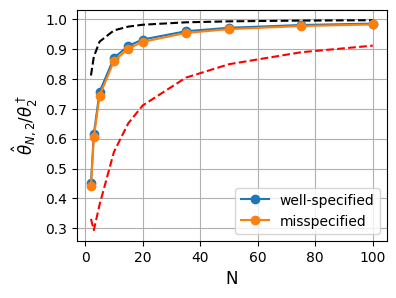

In [170]:
plt.figure(figsize=(4,3))
plt.plot(Nset0, dN_vals_gaussian, label='well-specified', marker='o', zorder=3)
# plt.axhline([1], color="#1f77b4", ls='--', label=r'$d_\infty$ (well-specified)')
plt.plot(Nset0, dN_vals_misspecified/d_infty_misspecified, label='misspecified', marker='o', zorder=5)
# plt.axhline([d_infty_misspecified], color="#ff7f0e", ls='--', label=r'$d_\infty$ (misspecified)')


c1, c2 = 0.18870747215298034*2, 0.9645481924893609*2
plt.plot(Nset0, 1-1/np.array(Nset0)*c1, 'k--')
plt.plot(Nset0, 1-np.log(Nset0)/np.array(Nset0)*c2, 'r--')

plt.grid()
plt.xlabel('N', fontsize=12)
plt.ylabel(r'$\hat{\theta}_{N,2}/\theta^\dagger_{2}$', fontsize=12)
plt.legend()
# plt.savefig(f'./fig_dN_location_scale.pdf', format='pdf', bbox_inches="tight", dpi=300)

# Well-specified

In [51]:
mu1, mu2, sigma1 = 0, 0, 1
sigma2s = np.linspace(0.1, 2, 101)

In [52]:
Nset = [2, 5, 10, 20, 50, 100]

In [53]:
true_loss_gaussiaNset = np.array([true_wass_loss_gaussian(mu1, sigma1, mu2, sigma2) for sigma2 in sigma2s])
expected_loss_gaussiaNset = {}
expected_loss_gaussian_minimizer_set = {}
for N in Nset:
    expected_loss_gaussiaNset[str(N)] = np.array([expected_W_emp_conti_gaussian(mu1, sigma1, mu2, sigma2, N, m1s=m1s_set[str(N)], q1s=q1s_set[str(N)]) for sigma2 in sigma2s])
    mu_hat, sigma_hat = analytic_sol_expected_W_emp_conti_gaussian(mu1, sigma1, N, m1s=m1s_set[str(N)], q1s = q1s_set[str(N)], alpha = 0)
    expected_loss_gaussian_minimizer_set[str(N)] = sigma_hat

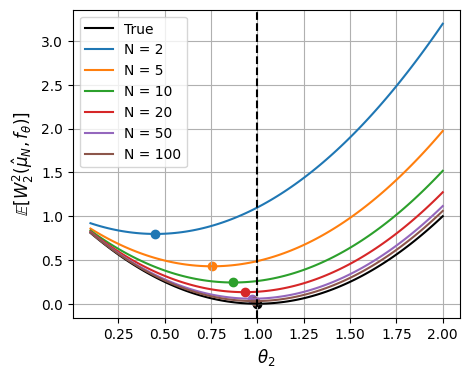

In [54]:
plt.figure(figsize=(5,4))
plt.plot(sigma2s, true_loss_gaussiaNset, 'k', label='True')
plt.scatter(sigma1, 0, marker='o', c='k')
for i, N in enumerate(Nset):
    plt.plot(sigma2s, expected_loss_gaussiaNset[str(N)], label=f'N = {N}')
    # plt.plot(sigma2s, np.mean(empirical_loss_gaussiaNset[str(N)], axis=1), '--', c=plt.gca().lines[-1].get_color())
    temp_sigma = expected_loss_gaussian_minimizer_set[str(N)]
    plt.scatter(temp_sigma, expected_W_emp_conti_gaussian(mu1, sigma1, mu2, temp_sigma, N, m1s=m1s_set[str(N)], q1s=q1s_set[str(N)]), marker='o')
plt.axvline([sigma1], color="k", linestyle="dashed")
plt.grid()
plt.xlabel(r'$\theta_2$', fontsize=12)
plt.ylabel(r'$\mathbb{E}[W_2^2(\hat{\mu}_{N}, f_{\theta})]$', fontsize=12)
plt.legend()
# plt.savefig(f'./fig_expected_loss_SD_wellspecified.pdf', format='pdf', bbox_inches="tight", dpi=300)

# Misspecified

In [44]:
theta = 1
mu2 = theta / np.sqrt(2)
sigma2s = np.linspace(0.1, 1.5, 101)

In [45]:
true_loss_misspecified_set = np.array([true_wass_loss_exponential_gaussian(mu2, sigma2, theta, d_infty_misspecified) for sigma2 in sigma2s])
mu_hat_infty, sigma_hat_infty = analytic_sol_exponential_gaussian(theta, d_infty_misspecified)
true_loss_infty = true_wass_loss_exponential_gaussian(mu2, sigma_hat_infty, theta, d_infty_misspecified)
expected_loss_misspecified_set = {}
expected_loss_misspecified_minimizer_set = {}
for N in Nset:
    expected_loss_misspecified_set[str(N)] = np.array([expected_W_emp_conti_exponential_gaussian(theta, mu2, sigma2, N, m1s_exp=b1s_exp_set[str(N)], q1s=q1s_set[str(N)]) for sigma2 in sigma2s])
    mu_hat, sigma_hat = analytic_sol_expected_W_emp_conti_exponential_gaussian(theta, N, m1s_exp=b1s_exp_set[str(N)], m1s=m1s_set[str(N)], q1s = q1s_set[str(N)], alpha = 0)
    expected_loss_misspecified_minimizer_set[str(N)] = sigma_hat

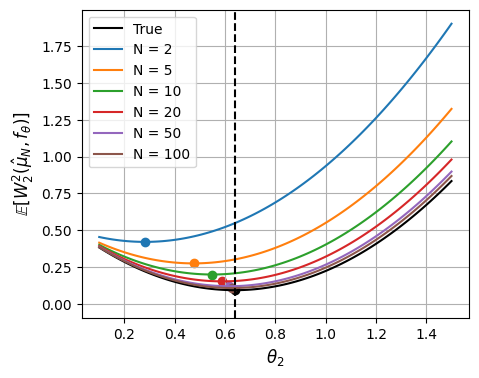

In [49]:
plt.figure(figsize=(5,4))
plt.plot(sigma2s, true_loss_misspecified_set, 'k', label='True')
plt.scatter(sigma_hat_infty, true_loss_infty, marker='o', c='k')
for i, N in enumerate(Nset):
    plt.plot(sigma2s, expected_loss_misspecified_set[str(N)], label=f'N = {N}')
    # plt.plot(sigma2s, np.mean(empirical_loss_gaussiaNset[str(N)], axis=1), '--', c=plt.gca().lines[-1].get_color())
    temp_sigma = expected_loss_misspecified_minimizer_set[str(N)]
    plt.scatter(temp_sigma, expected_W_emp_conti_exponential_gaussian(theta, mu2, temp_sigma, N, m1s_exp=b1s_exp_set[str(N)], q1s=q1s_set[str(N)]), marker='o')
plt.axvline([sigma_hat_infty], color="k", linestyle="dashed")
plt.scatter(sigma_hat_infty,0,color='w')
plt.grid()
plt.xlabel(r'$\theta_2$', fontsize=12)
plt.ylabel(r'$\mathbb{E}[W_2^2(\hat{\mu}_{N}, f_{\theta})]$', fontsize=12)
plt.legend()
# plt.savefig(f'./fig_expected_loss_SD_misspecified.pdf', format='pdf', bbox_inches="tight", dpi=300)

In [47]:
for i, N in enumerate(Nset):
    print(np.sum(b1s_exp_set[str(N)] * q1s_set[str(N)]) - expected_loss_misspecified_minimizer_set[str(N)])

0.0
0.0
0.0
0.0
0.0
0.0


# Bias reduction heuristic well-specified

In [81]:
Nset = [5,10,15,20,35,50,75,100]

In [82]:
sigma2_set = np.concatenate([np.linspace(0.25, 2, 200)])
temp_alpha_set = np.empty((len(sigma2_set), len(Nset)))
S_grad_set = np.empty((len(sigma2_set), len(Nset)))
J_SDa_set = np.empty((len(sigma2_set), len(Nset)))
for i, sigma2 in enumerate(sigma2_set):
    for j, N in enumerate(Nset):
        S_grad = expected_self_wasserstein_loss_gaussian_grad(mu2, sigma2, N, m1s=m1s_set[str(N)])
        J_SDa_grad = expected_W_emp_conti_gaussian_grad(mu1, sigma1, mu2, sigma2, N, m1s=m1s_set[str(N)], q1s=q1s_set[str(N)])
        temp_alpha = J_SDa_grad[1] / S_grad[1]
        temp_alpha_set[i,j] = temp_alpha
        S_grad_set[i,j] = S_grad[1]
        J_SDa_set[i,j] = J_SDa_grad[1]

In [83]:
sigma2_heu, fval = minimise_alpha_var(mu1, sigma1, mu2, Nset, m1s_set=m1s_set, q1s_set=q1s_set)
sigma2_heu

1.0027921596452423

In [84]:
temp_alpha_heu_set = np.empty(len(Nset))
for j, N in enumerate(Nset):
    S_grad_heu = expected_self_wasserstein_loss_gaussian_grad(mu2, sigma2_heu, N, m1s=m1s_set[str(N)])
    J_SDa_grad_heu = expected_W_emp_conti_gaussian_grad(mu1, sigma1, mu2, sigma2_heu, N, m1s=m1s_set[str(N)], q1s=q1s_set[str(N)])
    temp_alpha_heu_set[j] = J_SDa_grad_heu[1] / S_grad_heu[1]
alpha_heu = np.mean(temp_alpha_heu_set)
alpha_heu

0.31578873131757146

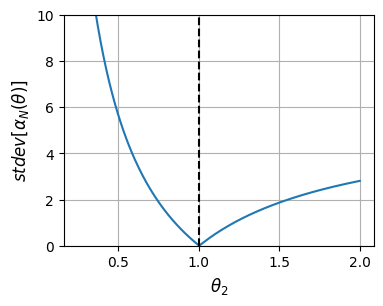

In [96]:
plt.figure(figsize=(4,3))
plt.plot(sigma2_set, np.std(temp_alpha_set, axis=-1))
plt.ylim(0,10)
plt.grid()
plt.xlabel(r'$\theta_2$', fontsize=12)
plt.ylabel(r'$stdev[\alpha_{N}(\theta)]$', fontsize=12)
plt.axvline([sigma1], color="k", linestyle="dashed")
# plt.legend()
# plt.savefig(f'./fig_expected_loss_SD_misspecified.pdf', format='pdf', bbox_inches="tight", dpi=300)

In [86]:
idx=0
sigma2 = sigma2_set[np.argsort(np.std(temp_alpha_set, axis=-1))[idx]]
sig_set = np.empty(len(Nset))
sig_bias_corrected_a0_5 = np.empty(len(Nset))
sig_bias_corrected_a = np.empty(len(Nset))
temp_alphas = np.empty(len(Nset))
alpha = alpha_heu
for i, N in enumerate(Nset):
    print(N)
    _, sig_set[i] = analytic_sol_expected_W_emp_conti_gaussian(mu1, sigma1, N, m1s=m1s_set[str(N)], q1s = q1s_set[str(N)])
    _, sig_bias_corrected_a0_5[i] = analytic_sol_expected_W_emp_conti_gaussian(mu1, sigma1, N, m1s=m1s_set[str(N)], q1s = q1s_set[str(N)], alpha = 0.5)
    
    S_grad = expected_self_wasserstein_loss_gaussian_grad(mu2, sigma2, N, m1s=m1s_set[str(N)])
    J_SDa_grad = expected_W_emp_conti_gaussian_grad(mu1, sigma1, mu2, sigma2, N, m1s=m1s_set[str(N)], q1s=q1s_set[str(N)])
    temp_alpha = J_SDa_grad[1] / S_grad[1]
    print(temp_alpha)
    _, sig_bias_corrected_a[i] = analytic_sol_expected_W_emp_conti_gaussian(mu1, sigma1, N, m1s=m1s_set[str(N)], q1s = q1s_set[str(N)], alpha = alpha)

5
0.3438200680086046
10
0.3239073083132238
15
0.319655693171279
20
0.3197494544975488
35
0.3281625149504801
50
0.34052791383330533
75
0.3636105544829396
100
0.3877447121876239


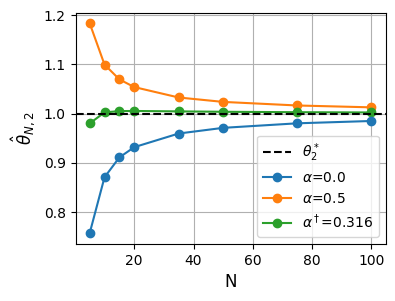

In [171]:
plt.figure(figsize=(4,3))
plt.axhline([sigma1], color='k', ls='--', label=r'$\theta_2^*$', zorder=20)
plt.plot(Nset, sig_set, label=r'$\alpha$=0.0', marker='o', zorder=10)
plt.plot(Nset, sig_bias_corrected_a0_5, label=r'$\alpha$=0.5', marker='o', zorder=3)
plt.plot(Nset, sig_bias_corrected_a, label=rf'$\alpha^\dagger$={alpha:.3f}', marker='o', zorder=5)
plt.grid()
plt.xlabel(f'N', fontsize=12)
plt.ylabel(r'$\hat{\theta}_{N,2}$', fontsize=12)
# plt.ylim(-1, -0.95)
plt.legend()
# plt.savefig(f'./fig_bias_reduction_SD_well.pdf', format='pdf', bbox_inches="tight", dpi=300)

# Bias reduction heuristic misspecified

In [99]:
Nset = [5,10,15,20,35,50,75,100]

In [144]:
sigma2_ms_set = np.concatenate([np.linspace(0.25*theta*d_infty_misspecified, 2*theta*d_infty_misspecified, 200)])
temp_alpha_ms_set = np.empty((len(sigma2_ms_set), len(Nset)))
S_grad_ms_set = np.empty((len(sigma2_ms_set), len(Nset)))
J_SDa_ms_set = np.empty((len(sigma2_ms_set), len(Nset)))
for i, sigma2 in enumerate(sigma2_ms_set):
    for j, N in enumerate(Nset):
        S_grad = expected_self_wasserstein_loss_gaussian_grad(mu2, sigma2, N, m1s=m1s_set[str(N)])
        J_SDa_grad = expected_W_emp_conti_exponential_gaussian_grad(theta, mu2, sigma2, N, m1s_exp=b1s_exp_set[str(N)], q1s=q1s_set[str(N)])
        temp_alpha = J_SDa_grad[1] / S_grad[1]
        temp_alpha_ms_set[i,j] = temp_alpha
        S_grad_ms_set[i,j] = S_grad[1]
        J_SDa_ms_set[i,j] = J_SDa_grad[1]

In [101]:
sigma2_ms_heu, fval_ms = minimise_alpha_var_misspecified(theta, mu2, Nset, m1s_exp_set=b1s_exp_set, m1s_set=m1s_set, q1s_set=q1s_set)
sigma2_ms_heu

0.6392931984107528

In [111]:
temp_alpha_heu_ms_set = np.empty(len(Nset))
for j, N in enumerate(Nset):
    S_grad_heu = expected_self_wasserstein_loss_gaussian_grad(mu2, sigma2_ms_heu, N, m1s=m1s_set[str(N)])
    J_SDa_grad_heu = expected_W_emp_conti_exponential_gaussian_grad(theta, mu2, sigma2_ms_heu, N, m1s_exp=b1s_exp_set[str(N)], q1s=q1s_set[str(N)])
    temp_alpha_heu_ms_set[j] = J_SDa_grad_heu[1] / S_grad_heu[1]
alpha_ms_heu = np.mean(temp_alpha_heu_ms_set)
alpha_ms_heu

0.3392971008758323

In [112]:
temp_alpha_heu_ms_set

array([0.3557219 , 0.33884045, 0.334254  , 0.33269515, 0.33296825,
       0.33523933, 0.33990127, 0.34475645])

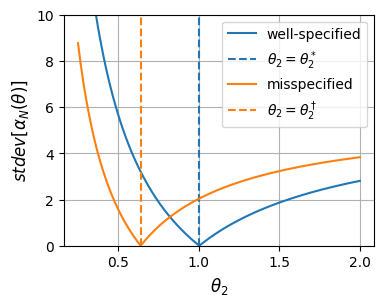

In [134]:
plt.figure(figsize=(4,3))
plt.plot(sigma2_set, np.std(temp_alpha_set, axis=-1), label='well-specified')
plt.axvline([sigma1], color="#1f77b4", linestyle="dashed", label=r'$\theta_2=\theta_2^*$')
plt.plot(sigma2_ms_set, np.std(temp_alpha_ms_set, axis=-1), label='misspecified')
plt.axvline([theta*d_infty_misspecified], color="#ff7f0e", linestyle="dashed", label=r'$\theta_2=\theta_2^\dagger$')
plt.ylim(0,10)
plt.grid()
plt.xlabel(r'$\theta_2$', fontsize=12)
plt.ylabel(r'$stdev[\alpha_{N}(\theta)]$', fontsize=12)
plt.legend()
# plt.savefig(f'./fig_stdev_alpha_SD.pdf', format='pdf', bbox_inches="tight", dpi=300)

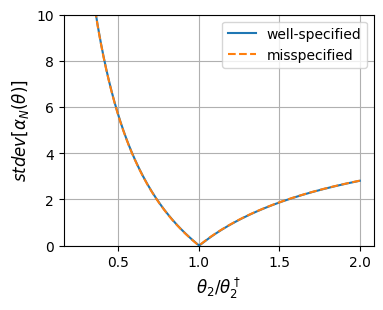

In [159]:
plt.figure(figsize=(4,3))
plt.plot(sigma2_set/sigma1, np.std(temp_alpha_set, axis=-1), label='well-specified')
# plt.axvline([sigma1], color="#1f77b4", linestyle="dashed", label=r'$\theta_2=\theta_2^*$')
plt.plot(sigma2_ms_set/theta/d_infty_misspecified, np.std(temp_alpha_ms_set, axis=-1), ls='--', label='misspecified')
# plt.axvline([theta*d_infty_misspecified], color="#ff7f0e", linestyle="dashed", label=r'$\theta_2=\theta_2^\dagger$')
# plt.plot(sigma2_set, 6*np.abs(sigma2_set-1)/sigma2_set, 'k--.')
plt.ylim(0,10)
plt.grid()
plt.xlabel(r'$\theta_2/\theta_2^\dagger$', fontsize=12)
plt.ylabel(r'$stdev[\alpha_{N}(\theta)]$', fontsize=12)
plt.legend()
# plt.ylim(2.5,2.52)
# plt.savefig(f'./fig_stdev_alpha_SD.pdf', format='pdf', bbox_inches="tight", dpi=300)

In [114]:
idx=0
sigma2_ms = sigma2_ms_set[np.argsort(np.std(temp_alpha_ms_set, axis=-1))[idx]]
sig_ms_set = np.empty(len(Nset))
sig_bias_corrected_a0_5_ms = np.empty(len(Nset))
sig_bias_corrected_a_ms = np.empty(len(Nset))
temp_alphas_ms = np.empty(len(Nset))
alpha_ms = alpha_ms_heu
for i, N in enumerate(Nset):
    print(N)
    _, sig_ms_set[i] = analytic_sol_expected_W_emp_conti_exponential_gaussian(theta, N, m1s_exp=b1s_exp_set[str(N)], m1s=m1s_set[str(N)], q1s = q1s_set[str(N)], alpha = 0)
    _, sig_bias_corrected_a0_5_ms[i] =analytic_sol_expected_W_emp_conti_exponential_gaussian(theta, N, m1s_exp=b1s_exp_set[str(N)], m1s=m1s_set[str(N)], q1s = q1s_set[str(N)], alpha = 0.5)
    
    S_grad = expected_self_wasserstein_loss_gaussian_grad(mu2, sigma2, N, m1s=m1s_set[str(N)])
    J_SDa_grad = expected_W_emp_conti_exponential_gaussian_grad(theta, mu2, sigma2, N, m1s_exp=b1s_exp_set[str(N)], q1s=q1s_set[str(N)])
    temp_alpha_ms = J_SDa_grad[1] / S_grad[1]
    print(temp_alpha_ms)
    _, sig_bias_corrected_a_ms[i] = analytic_sol_expected_W_emp_conti_exponential_gaussian(theta, N, m1s_exp=b1s_exp_set[str(N)], m1s=m1s_set[str(N)], q1s = q1s_set[str(N)], alpha = alpha_ms)

5
1.0560545043096081
10
1.7392825479583918
15
2.3962515471751593
20
3.0366048140936686
35
4.89768063315692
50
6.704065307212335
75
9.643589088650124
100
12.525379607867944


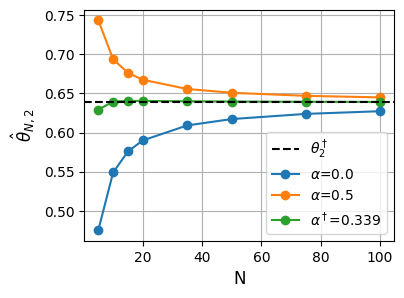

In [172]:
plt.figure(figsize=(4,3))
plt.axhline([theta*d_infty_misspecified], color='k', ls='--', label=r'$\theta_2^\dagger$', zorder=20)
plt.plot(Nset, sig_ms_set, label=r'$\alpha$=0.0', marker='o', zorder=10)
plt.plot(Nset, sig_bias_corrected_a0_5_ms, label=r'$\alpha$=0.5', marker='o', zorder=3)
plt.plot(Nset, sig_bias_corrected_a_ms, label=rf'$\alpha^\dagger$={alpha_ms:.3f}', marker='o', zorder=5)
plt.grid()
plt.xlabel(f'N', fontsize=12)
plt.ylabel(r'$\hat{\theta}_{N,2}$', fontsize=12)
# plt.ylim(-1, -0.95)
plt.legend()
# plt.savefig(f'./fig_bias_reduction_SD_mis.pdf', format='pdf', bbox_inches="tight", dpi=300)